In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles.csv")
df.head

# Data Information
df.info()

# Check Missing Values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


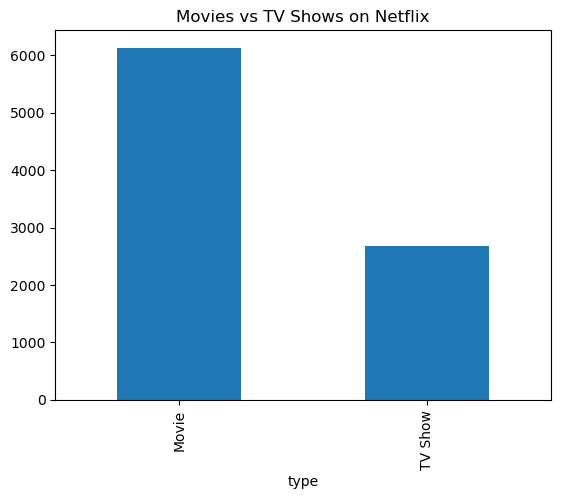

Insight:
 - Movies are significantly higher in number compared to TV Shows on Netflix.
 - This indicates that Netflix invests more in movie content.


In [2]:
# Business-Oriented Analysis Questions
# 1.Content strategy 
# 1.What is the ratio of Movies vs TV Shows on Netflix?
type_count = df['type'].value_counts()
print(type_count)

type_count.plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

print("Insight:") 
print(" - Movies are significantly higher in number compared to TV Shows on Netflix.")
print(" - This indicates that Netflix invests more in movie content.")


listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


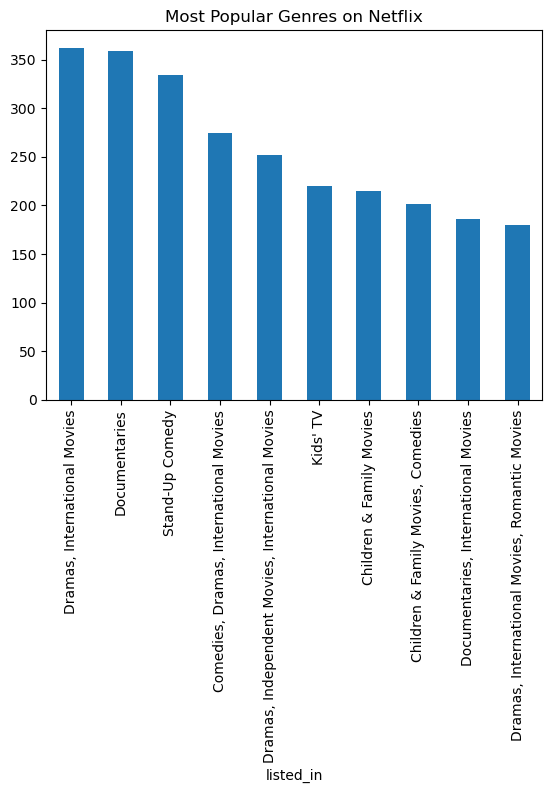

Insight:
 - Some genres appear more frequently in the dataset compared to others.
 - These genres represent the most popular content categories on Netflix.


In [3]:
# 2. Which genres are most popular on Netflix globally?
genre_count = df['listed_in'].value_counts().head(10)
print(genre_count)

genre_count.plot(kind='bar')
plt.title("Most Popular Genres on Netflix")
plt.show()

print("Insight:")
print(" - Some genres appear more frequently in the dataset compared to others.")
print(" - These genres represent the most popular content categories on Netflix.")

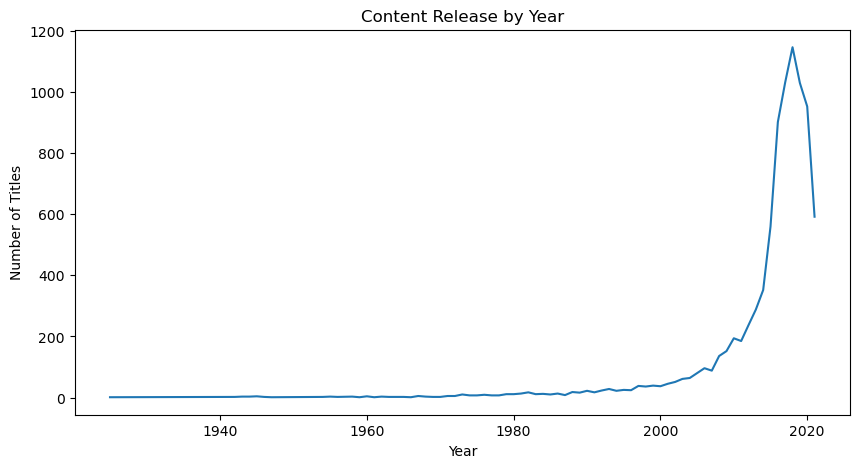

 Insight:
 - The number of releases increased significantly in recent years
 - This shows Netflix expanded its content library rapidly..


In [4]:
# 3.Which years saw the highest release of content on Netflix?
year_count = df['release_year'].value_counts().sort_index()

year_count.plot(figsize=(10,5))
plt.title("Content Release by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

print(" Insight:")
print(" - The number of releases increased significantly in recent years")
print(" - This shows Netflix expanded its content library rapidly..")

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


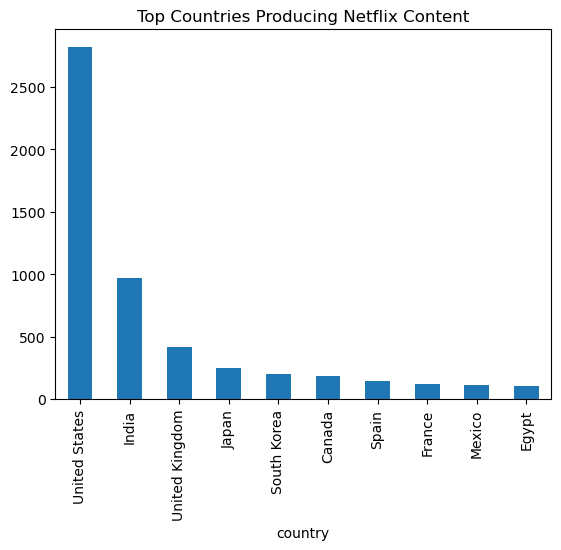

Insight:
 - Some countries contribute more content compared to others.
 - These countries are major producers of Netflix shows and movies..


In [5]:
# 4. Which countries produce the most Netflix content?
country_count = df['country'].value_counts().head(10)
print(country_count)

country_count.plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")
plt.show()

print("Insight:")
print(" - Some countries contribute more content compared to others.")
print(" - These countries are major producers of Netflix shows and movies..")

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


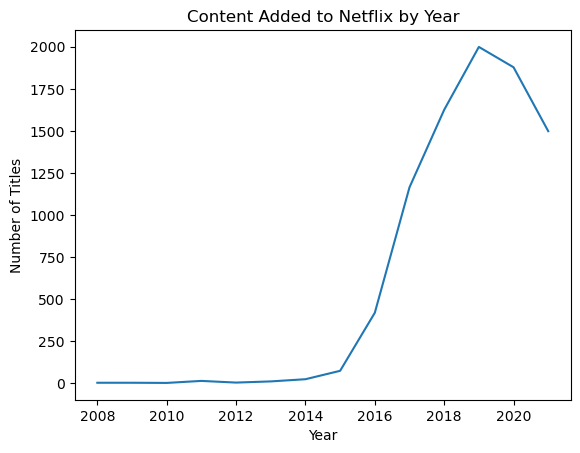

Insight:
 - Netflix started adding more titles every year over time.
 - This reflects the platform's rapid growth and expansion.


In [6]:
# 5. How has the trend of adding new content evolved year by year?
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

trend = df['year_added'].value_counts().sort_index()

print(trend)

trend.plot(kind='line')
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()
print("Insight:")
print(" - Netflix started adding more titles every year over time.")
print(" - This reflects the platform's rapid growth and expansion.")

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


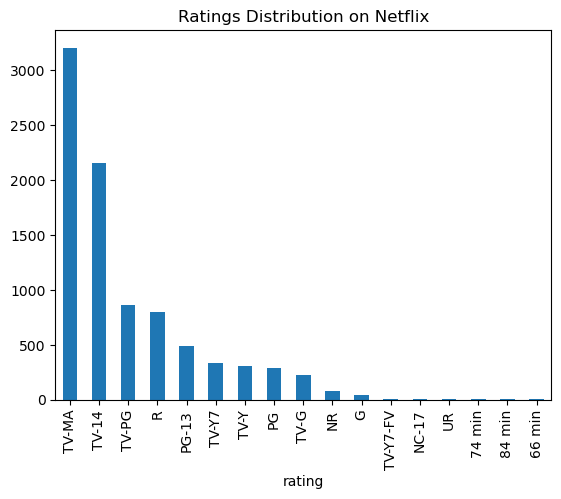

Insight:
 - TV-MA and TV-14 ratings appear most frequently.
 - This means Netflix mainly targets adult and teenage audiences.


In [7]:
# 2. User Demographics & Targetting 
# 6.Which ratings are most frequent on Netflix?
rating_count = df['rating'].value_counts()

print(rating_count)

rating_count.plot(kind='bar')
plt.title("Ratings Distribution on Netflix")
plt.show()

print("Insight:")
print(" - TV-MA and TV-14 ratings appear most frequently.")
print(" - This means Netflix mainly targets adult and teenage audiences.")

country
United States     928
India             248
United Kingdom    177
Spain             119
Japan              87
South Korea        85
France             80
Mexico             77
Turkey             63
Canada             61
Name: count, dtype: int64


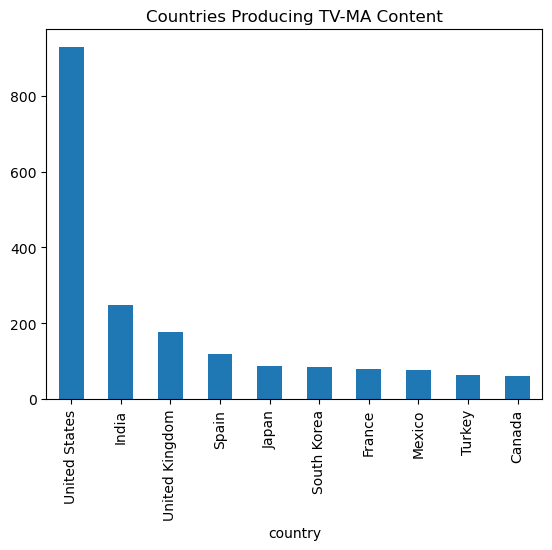

Insight:
 - Some countries produce more mature rated content.
 - These countries focus more on adult audience entertainment.


In [8]:
#7.Do some countries tend to produce more mature content (TV-MA)?
tv_ma = df[df['rating'] == 'TV-MA']
country_tvma = tv_ma['country'].value_counts().head(10)

print(country_tvma)

country_tvma.plot(kind='bar')
plt.title("Countries Producing TV-MA Content")
plt.show()

print("Insight:")
print(" - Some countries produce more mature rated content.")
print(" - These countries focus more on adult audience entertainment.")

In [9]:
# 8.Which genres are more associated with TV Shows vs Movies?
genre_type = df.groupby('type')['listed_in'].value_counts().head(10)

print(genre_type)

print("Insight:")
print(" - Different genres appear more in movies and television shows.")
print(" - This shows different storytelling formats for each type.")

type   listed_in                                       
Movie  Dramas, International Movies                        362
       Documentaries                                       359
       Stand-Up Comedy                                     334
       Comedies, Dramas, International Movies              274
       Dramas, Independent Movies, International Movies    252
       Children & Family Movies                            215
       Children & Family Movies, Comedies                  201
       Documentaries, International Movies                 186
       Dramas, International Movies, Romantic Movies       180
       Comedies, International Movies                      176
Name: count, dtype: int64
Insight:
 - Different genres appear more in movies and television shows.
 - This shows different storytelling formats for each type.


listed_in
Documentaries                         249
Stand-Up Comedy                       209
Children & Family Movies, Comedies     90
Dramas                                 88
Comedies                               84
Children & Family Movies               80
Kids' TV                               77
Dramas, Independent Movies             74
Reality TV                             71
Action & Adventure                     64
Name: count, dtype: int64


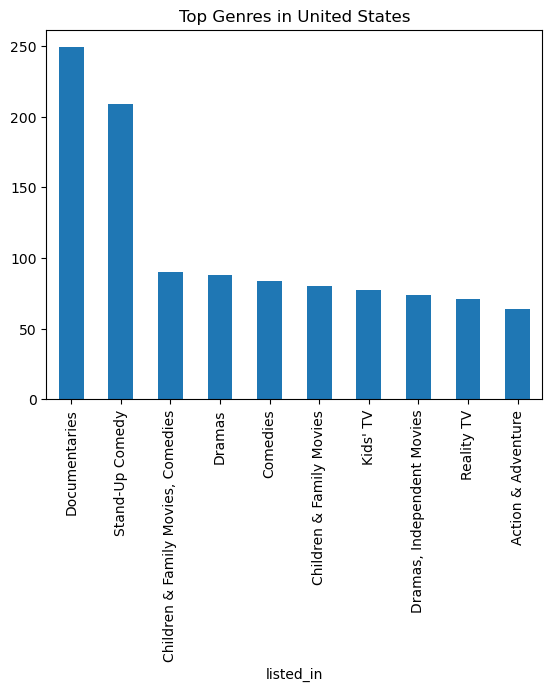

Insight:
 - Certain genres dominate content produced in the United States.
 - These genres represent popular entertainment categories.


In [10]:
# 9.Which genres dominate the United States vs other countries?
us_data = df[df['country'] == 'United States']
us_genre = us_data['listed_in'].value_counts().head(10)

print(us_genre)

us_genre.plot(kind='bar')
plt.title("Top Genres in United States")
plt.show()

print("Insight:")
print(" - Certain genres dominate content produced in the United States.")
print(" - These genres represent popular entertainment categories.")


listed_in
Stand-Up Comedy                                      159
Documentaries                                        130
Dramas, International Movies                         124
Kids' TV                                             105
Dramas, Independent Movies, International Movies     101
Children & Family Movies                              97
Comedies, Dramas, International Movies                95
Children & Family Movies, Comedies                    73
Dramas, International Movies, Romantic Movies         72
Crime TV Shows, International TV Shows, TV Dramas     70
Name: count, dtype: int64


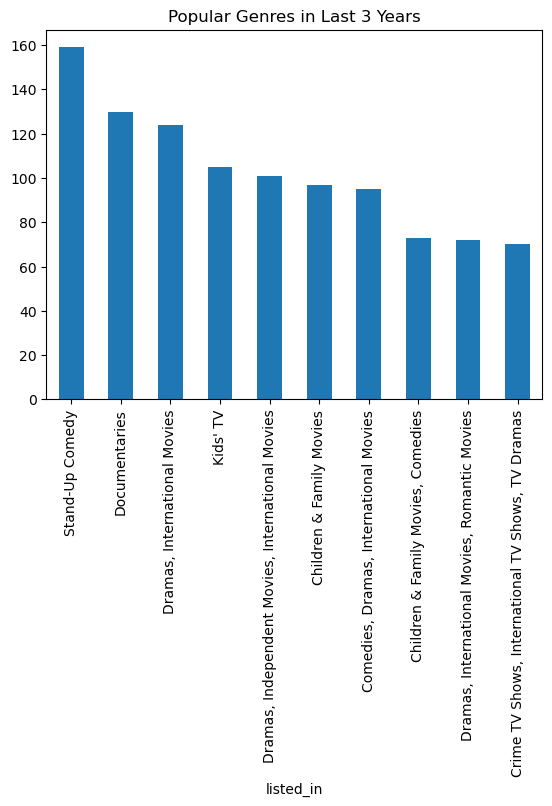

Insight:
 - Some genres are more popular in recent years.
 - This shows changing viewer preferences.


In [11]:
# .10 What genres are most popular in the last 3 years?
recent = df[df['release_year'] >= df['release_year'].max() - 3]
recent_genre = recent['listed_in'].value_counts().head(10)

print(recent_genre)

recent_genre.plot(kind='bar')
plt.title("Popular Genres in Last 3 Years")
plt.show()

print("Insight:")
print(" - Some genres are more popular in recent years.")
print(" - This shows changing viewer preferences.")

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


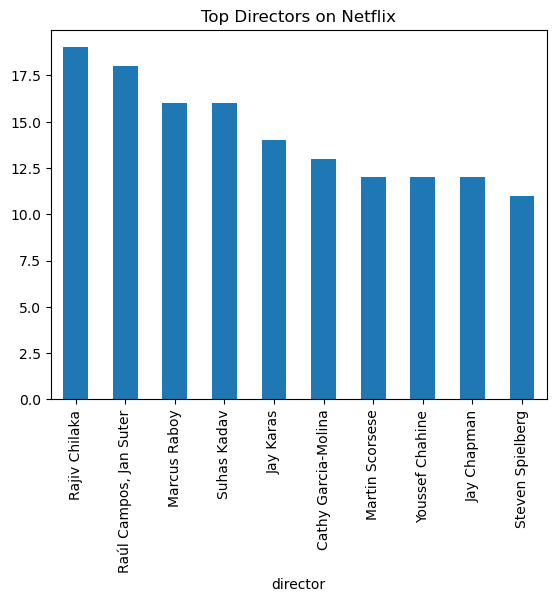

Insight:
 - Some directors have created many titles on Netflix.
 - These directors contribute significantly to the platform.


In [12]:
# 3. Talent Acquisition & Partnerships
# 11. Who are the top 10 directors with the most Netflix content?
director_count = df['director'].value_counts().head(10)

print(director_count)

director_count.plot(kind='bar')
plt.title("Top Directors on Netflix")
plt.show()

print("Insight:")
print(" - Some directors have created many titles on Netflix.")
print(" - These directors contribute significantly to the platform.")

 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
 Rajesh Kava         26
Shah Rukh Khan       26
 Yuki Kaji           25
 Paresh Rawal        25
 Andrea Libman       25
Name: count, dtype: int64


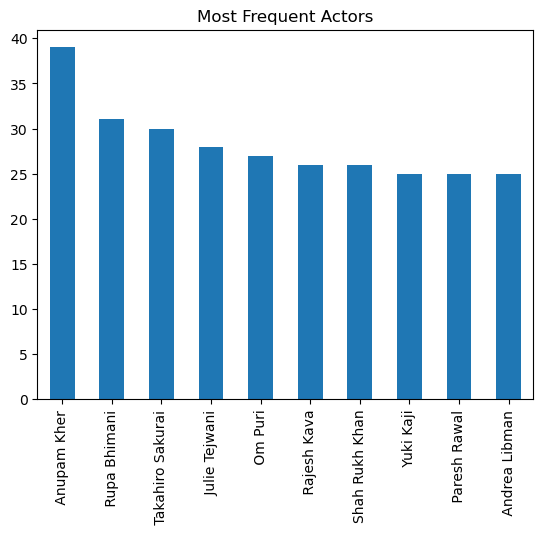

Insight:
 - Some actors appear repeatedly in Netflix titles.
 - These actors are frequently cast in popular shows.


In [13]:
# 12. Which actors appear most frequently in Netflix shows?
cast = df['cast'].dropna().str.split(',', expand=True).stack()
top_actors = cast.value_counts().head(10)

print(top_actors)

top_actors.plot(kind='bar')
plt.title("Most Frequent Actors")
plt.show()

print("Insight:")
print(" - Some actors appear repeatedly in Netflix titles.")
print(" - These actors are frequently cast in popular shows.")

In [14]:
# 13. Which director-genre pairs are most frequent?
pair = df.groupby(['director','listed_in']).size().sort_values(ascending=False).head(10)

print(pair)

print("Insight:")
print(" - Some directors frequently work within specific genres.")
print(" - This shows strong creative specialization.")

director                listed_in                                       
Raúl Campos, Jan Suter  Stand-Up Comedy                                     18
Rajiv Chilaka           Children & Family Movies                            18
Marcus Raboy            Stand-Up Comedy                                     15
Jay Karas               Stand-Up Comedy                                     13
Jay Chapman             Stand-Up Comedy                                     11
Shannon Hartman         Stand-Up Comedy                                      8
Lance Bangs             Stand-Up Comedy                                      7
S.S. Rajamouli          Action & Adventure, Dramas, International Movies     7
Ryan Polito             Stand-Up Comedy                                      7
Troy Miller             Stand-Up Comedy                                      7
dtype: int64
Insight:
 - Some directors frequently work within specific genres.
 - This shows strong creative specialization.


In [15]:
# 14.How many titles have unknown directors or cast members?
unknown_director = df['director'].isnull().sum()
unknown_cast = df['cast'].isnull().sum()

print("Unknown Directors:", unknown_director)
print("Unknown Cast:", unknown_cast)

print("Insight:")
print(" - Several titles have missing director or cast information.")
print(" - This indicates incomplete data in the dataset.")

Unknown Directors: 2634
Unknown Cast: 825
Insight:
 - Several titles have missing director or cast information.
 - This indicates incomplete data in the dataset.


In [16]:
# 4. Duration & Engagement 
# 15. What is the average duration of Movies on Netflix?
movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

avg_duration = movies['duration'].mean()

print("Average Movie Duration:", avg_duration)

print("Insight:")
print(" - The average movie duration is close to a standard film length.")
print(" - Most movies fall within typical viewing time.")


Average Movie Duration: 99.57718668407311
Insight:
 - The average movie duration is close to a standard film length.
 - Most movies fall within typical viewing time.


In [17]:
# 16. What is the most common number of seasons for TV shows?
tv = df[df['type'] == 'TV Show']
season_count = tv['duration'].value_counts().head(10)

print(season_count)

print("Insight:")
print(" - Many television shows have one or two seasons.")
print(" - Short series formats are common on Netflix.")

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
Name: count, dtype: int64
Insight:
 - Many television shows have one or two seasons.
 - Short series formats are common on Netflix.


release_year
1942    35.000000
1943    62.666667
1944    52.000000
1945    51.333333
1946    58.000000
          ...    
2017    95.535248
2018    96.185137
2019    93.466035
2020    92.141199
2021    96.444043
Name: duration, Length: 73, dtype: float64


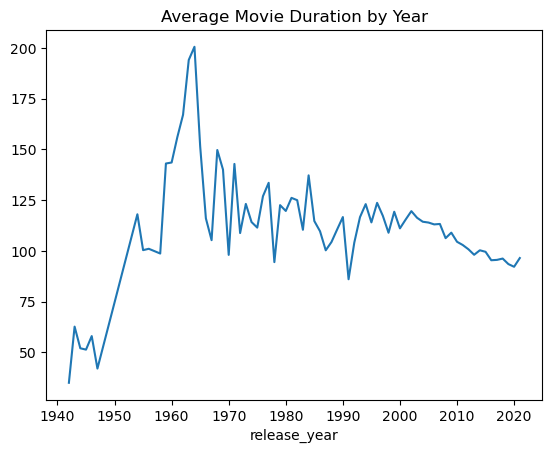

Insight:
 - Movie duration slightly changes over different years.
 - This reflects evolving storytelling styles.


In [18]:
# 17. Is there a trend in movie durations over the years?
movie_trend = movies.groupby('release_year')['duration'].mean()

print(movie_trend)

movie_trend.plot(kind='line')
plt.title("Average Movie Duration by Year")
plt.show()

print("Insight:")
print(" - Movie duration slightly changes over different years.")
print(" - This reflects evolving storytelling styles.")

month_added
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64


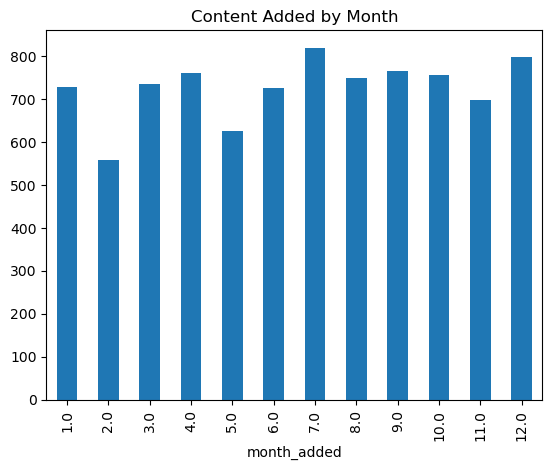

Insight:
 - Some months have higher content additions.
 - Netflix schedules releases strategically.


In [19]:
# 5. Content Launch Strategy
# 18. In which months does Netflix add the most content?
df['month_added'] = df['date_added'].dt.month
month_count = df['month_added'].value_counts().sort_index()

print(month_count)

month_count.plot(kind='bar')
plt.title("Content Added by Month")
plt.show()

print("Insight:")
print(" - Some months have higher content additions.")
print(" - Netflix schedules releases strategically.")

In [20]:
# 19. How does genre distribution vary across different years?
genre_year = df.groupby(['release_year','listed_in']).size().head(10)

print(genre_year)

print("Insight:")
print(" - Different genres become popular in different years.")
print(" - Audience preferences change over time.")

release_year  listed_in                    
1925          TV Shows                         1
1942          Classic Movies, Documentaries    2
1943          Classic Movies, Documentaries    1
              Documentaries                    2
1944          Classic Movies, Documentaries    3
1945          Classic Movies, Documentaries    3
              TV Shows                         1
1946          Classic Movies, Documentaries    1
              TV Shows                         1
1947          Classic Movies, Documentaries    1
dtype: int64
Insight:
 - Different genres become popular in different years.
 - Audience preferences change over time.


In [21]:
#  20. Which countries produce the most content in each genre?
country_genre = df.groupby(['country','listed_in']).size().sort_values(ascending=False).head(10)

print(country_genre)

print("Insight:")
print(" - Some countries specialize in certain genres.")
print(" - This reflects regional strengths in content production.")

country        listed_in                                       
United States  Documentaries                                       249
               Stand-Up Comedy                                     209
India          Comedies, Dramas, International Movies              120
               Dramas, International Movies                        118
               Dramas, Independent Movies, International Movies    108
United States  Children & Family Movies, Comedies                   90
               Dramas                                               88
               Comedies                                             84
               Children & Family Movies                             80
               Kids' TV                                             77
dtype: int64
Insight:
 - Some countries specialize in certain genres.
 - This reflects regional strengths in content production.
